In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error

In [5]:
from styleplot import style_plot

In [4]:
# ============================================================
# 1. CREATE SYNTHETIC DATASET
# ============================================================

np.random.seed(42)

n_samples = 200

X = pd.DataFrame({
    "Tempo": np.random.uniform(60, 180, n_samples),
    "Danceability": np.random.uniform(0, 1, n_samples),
    "Energy": np.random.uniform(0, 1, n_samples),
    "Acousticness": np.random.uniform(0, 1, n_samples),
    "Valence": np.random.uniform(0, 1, n_samples),
    "Instrumentalness": np.random.uniform(0, 1, n_samples),
    "Liveness": np.random.uniform(0, 1, n_samples),
    "Speechiness": np.random.uniform(0, 1, n_samples)
})

# True signal comes from:
# Tempo, Danceability, Energy
noise = np.random.normal(0, 8, n_samples)

y = (
    -20
    + 0.25 * X["Tempo"]
    + 25 * X["Danceability"]
    + 30 * X["Energy"]
    + noise
)

# Keep popularity within the requested 0–100 range
y = np.clip(y, 0, 100)

y = pd.Series(y, name="Song_Popularity")


# ============================================================
# 2. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 3. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# ============================================================
# 4. RIDGE SWEEP
# ============================================================

def ridge_sweep(X_train, X_test, y_train, y_test, alphas):
    """
    Fit Ridge regression across a range of alpha values.

    Returns
    -------
    coefficients : ndarray
        Coefficient values for every alpha.
    train_errors : ndarray
        Training RMSE for every alpha.
    test_errors : ndarray
        Test RMSE for every alpha.
    """

    coefficients = []
    train_errors = []
    test_errors = []

    for alpha in alphas:

        model = Ridge(alpha=alpha)

        model.fit(X_train, y_train)

        # Store coefficients
        coefficients.append(model.coef_)

        # Predictions
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

        # RMSE
        train_rmse = np.sqrt(
            mean_squared_error(y_train, train_pred)
        )

        test_rmse = np.sqrt(
            mean_squared_error(y_test, test_pred)
        )

        train_errors.append(train_rmse)
        test_errors.append(test_rmse)

    return (
        np.array(coefficients),
        np.array(train_errors),
        np.array(test_errors)
    )


# ============================================================
# 5. LASSO SWEEP
# ============================================================

def lasso_sweep(X_train, X_test, y_train, y_test, alphas):
    """
    Fit LASSO regression across a range of alpha values.

    Returns
    -------
    coefficients : ndarray
        Coefficient values for every alpha.
    train_errors : ndarray
        Training RMSE for every alpha.
    test_errors : ndarray
        Test RMSE for every alpha.
    """

    coefficients = []
    train_errors = []
    test_errors = []

    for alpha in alphas:

        model = Lasso(
            alpha=alpha,
            max_iter=10000
        )

        model.fit(X_train, y_train)

        # Store coefficients
        coefficients.append(model.coef_)

        # Predictions
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

        # RMSE
        train_rmse = np.sqrt(
            mean_squared_error(y_train, train_pred)
        )

        test_rmse = np.sqrt(
            mean_squared_error(y_test, test_pred)
        )

        train_errors.append(train_rmse)
        test_errors.append(test_rmse)

    return (
        np.array(coefficients),
        np.array(train_errors),
        np.array(test_errors)
    )


# ============================================================
# 6. ERROR PLOT
# ============================================================

def plot_errors(alphas, train_errors, test_errors):
    """
    Plot training and test RMSE across alpha values.
    """

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(
        alphas,
        train_errors,
        label="Train RMSE"
    )

    ax.plot(
        alphas,
        test_errors,
        label="Test RMSE"
    )

    ax.set_xscale("log")

    style_plot(
        ax,
        title = "Regularization Error Across Alpha Values",
        xlabel = "Alpha",
        ylabel = "RMSE"
    )

    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [6]:
# ============================================================
# 7. DEFINE ALPHA VALUES
# ============================================================

alphas = np.logspace(-4, 2, 100)

In [14]:
# ============================================================
# 8. RUN RIDGE SWEEP
# ============================================================

ridge_coefficients, ridge_train_errors, ridge_test_errors = ridge_sweep(
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    alphas
)


In [15]:
# ============================================================
# 9. RUN LASSO SWEEP
# ============================================================

lasso_coefficients, lasso_train_errors, lasso_test_errors = lasso_sweep(
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    alphas
)

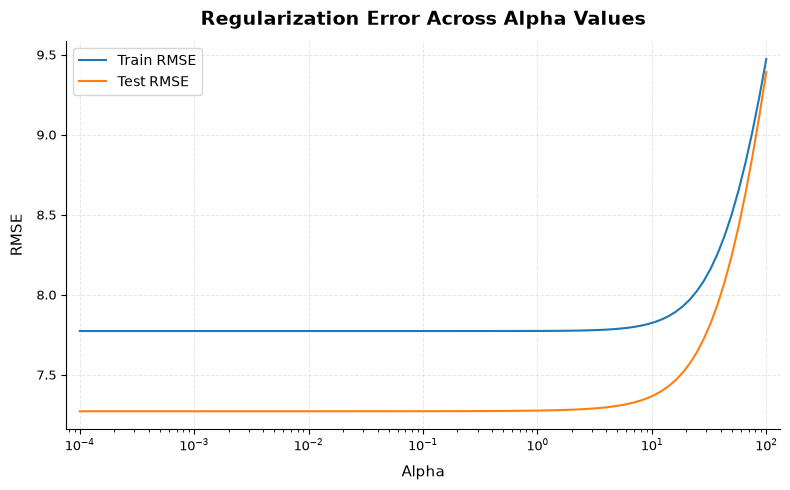

In [16]:
# ============================================================
# 10. PLOT RIDGE ERRORS
# ============================================================

plot_errors(
    alphas,
    ridge_train_errors,
    ridge_test_errors
)


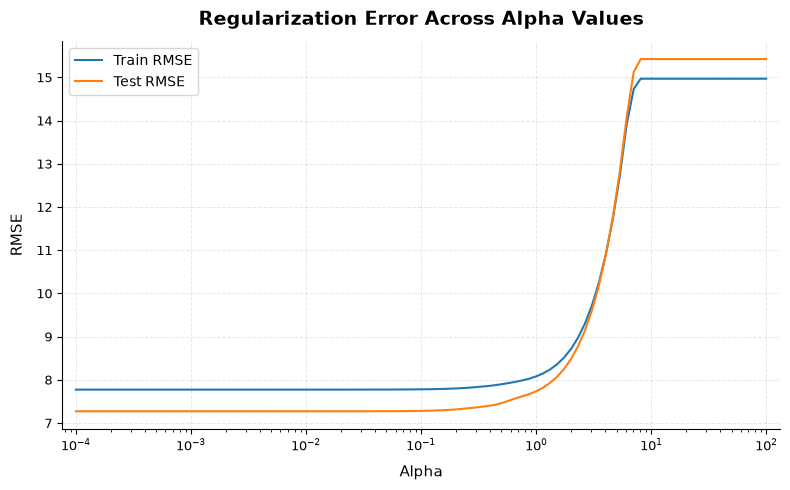

In [17]:
# ============================================================
# 11. PLOT LASSO ERRORS
# ============================================================

plot_errors(
    alphas,
    lasso_train_errors,
    lasso_test_errors
)

In [5]:
def download():
    import urllib.request

    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/olubunmi-thomas/life_expectancy_analysis/main/data/df_train.csv",
        "df_train.csv"
    )

    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/olubunmi-thomas/life_expectancy_analysis/main/data/df_test.csv",
        "df_test.csv"
    )

    return

In [6]:
download()

In [7]:
def _():
    import pandas as pd
    import numpy as np
    import matplotlib
    matplotlib.use('Agg')  # headless rendering for test environments
    import matplotlib.pyplot as plt
    from sklearn.linear_model import LinearRegression, Ridge, Lasso
    from sklearn.metrics import r2_score, mean_squared_error
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    import pickle
    import warnings
    warnings.filterwarnings('ignore')

    train_path = 'df_train.csv'  # Replace with your file path
    test_path  = 'df_test.csv'   # Replace with your file path

    df_train_raw = pd.read_csv(train_path, index_col=0)
    df_test_raw  = pd.read_csv(test_path,  index_col=0)

    def prepare_data(df):
        """Encode categorical columns and impute missing values with column medians."""
        df = df.copy()
        df = df.drop(columns=['time'], errors='ignore')
        df['Hawassa_wind_deg']  = df['Hawassa_wind_deg'].str.extract(r'(\d+)').astype(float)
        df['Kilimani_pressure'] = df['Kilimani_pressure'].str.extract(r'(\d+)').astype(float)
        df = df.fillna(df.median(numeric_only=True))
        return df

    df_train = prepare_data(df_train_raw)
    df_test  = prepare_data(df_test_raw)

    print('Train shape:', df_train.shape)
    print('Test shape: ', df_test.shape)
    return df_test_raw, df_train, np

In [8]:
_()

Train shape: (8763, 57)
Test shape:  (2920, 56)


(                     time  Sokoto_temp  Sokoto_temp_min  Sokoto_temp_max  \
 0     2022-01-01 00:00:00   291.313083       291.067883       292.437757   
 1     2022-01-01 03:00:00   295.471348       295.058682       296.377487   
 2     2022-01-01 06:00:00   297.691108       297.688239       299.090591   
 3     2022-01-01 09:00:00   300.235963       298.966004       300.540915   
 4     2022-01-01 12:00:00   300.545284       299.078910       302.283899   
 ...                   ...          ...              ...              ...   
 2915  2022-12-31 09:00:00   295.161032       294.068277       295.885705   
 2916  2022-12-31 12:00:00   295.171291       293.789580       295.660898   
 2917  2022-12-31 15:00:00   304.999233       304.158232       306.155763   
 2918  2022-12-31 18:00:00   299.806464       298.026563       300.803579   
 2919  2022-12-31 21:00:00   298.136703       297.066344       299.999116   
 
       Sokoto_humidity  Sokoto_clouds_all  Sokoto_wind_speed  Sokoto_rain_